In [1]:
!pip install qiskit --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.4 MB/s eta 0:00:00


In [2]:
!pip install pylatexenc --quiet
!pip install qiskit-aer --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 105.8 MB/s eta 0:00:00


Experiment 1

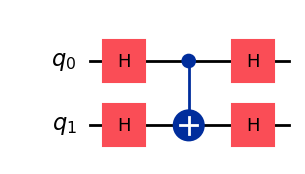

In [3]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

qc = QuantumCircuit(2)

# Apply Hadamard to both qubits
qc.h(0)
qc.h(1)

# Normal CNOT
qc.cx(0, 1)

# Apply Hadamard again
qc.h(0)
qc.h(1)

qc.draw('mpl')

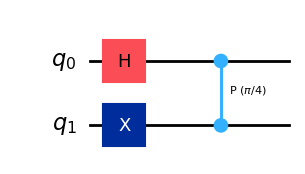

In [4]:
from qiskit import QuantumCircuit
import numpy as np

qc = QuantumCircuit(2)

# Put control qubit in superposition
qc.h(0)

# Prepare target in |1>
qc.x(1)

# Controlled phase (T gate = pi/4)
qc.cp(np.pi/4, 0, 1)

qc.draw('mpl')

Experiment 2

Deutsch Output: {'1': 1024}


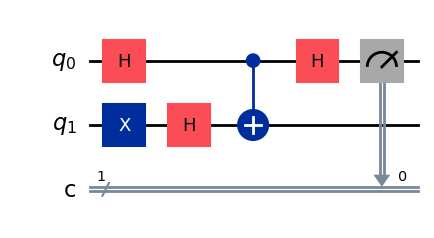

In [5]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit import transpile

qc = QuantumCircuit(2, 1)

# Step 1: Initialize
qc.x(1)
qc.h([0, 1])

# Step 2: Oracle (Balanced: f(x)=x)
qc.cx(0, 1)

# Step 3: Hadamard
qc.h(0)

# Step 4: Measurement
qc.measure(0, 0)

# Simulation
sim = Aer.get_backend('aer_simulator')
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()

counts = result.get_counts()
print("Deutsch Output:", counts)

qc.draw('mpl')

Experiment 3

Deutsch-Jozsa Output: {'111': 1024}


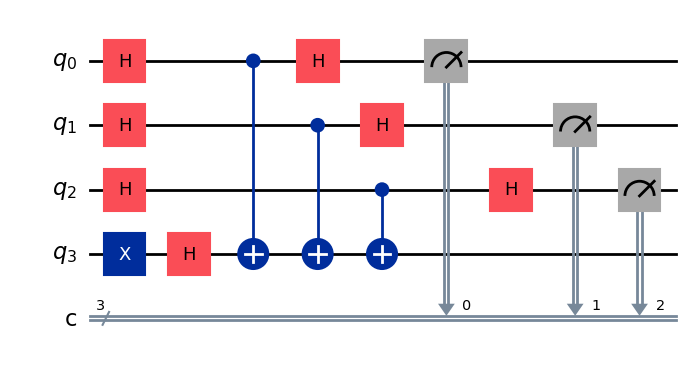

In [6]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit import transpile

n = 3  # number of input qubits
qc = QuantumCircuit(n+1, n)

# Step 1: Initialize
qc.x(n)
qc.h(range(n+1))

# Step 2: Oracle (Balanced example)
for i in range(n):
    qc.cx(i, n)

# Step 3: Hadamard on input qubits
qc.h(range(n))

# Step 4: Measurement
qc.measure(range(n), range(n))

# Simulation
sim = Aer.get_backend('aer_simulator')
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()

counts = result.get_counts()
print("Deutsch-Jozsa Output:", counts)

qc.draw('mpl')